## Import packages

In [4]:
import sys
sys.path.append('..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
from tensorflow.keras.models import load_model
from src import fetch_stock_data, fetch_realtime_data
from src import predict_next_price

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})

## Load tuned model, scaler, and config

In [5]:
model = load_model('../models/best_model.keras')
scaler = joblib.load('../models/best_scaler.pkl')

with open('../models/best_config.json', 'r') as f:
    config = json.load(f)

ticker = config['ticker']
seq_length = config['seq_length']
selected_features = config['features']

print("Model loaded successfully")
print(f"Ticker: {ticker}")
print(f"Sequence length: {seq_length}")
print(f"Features: {selected_features}")
print(f"Training RMSE: ${config['rmse']:.2f}")
print(f"Training MAE: ${config['mae']:.2f}")
print(f"MAPE: {config['mape']:.2f}%")
print(f"Prediction Accuracy: {config['accuracy_pct']:.2f}%")

Model loaded successfully
Ticker: AAPL
Sequence length: 60
Features: ['Close', 'Volume_SMA_20', 'Volume', 'MACD_Signal']
Training RMSE: $6.89
Training MAE: $5.38
MAPE: 2.14%
Prediction Accuracy: 97.86%


## Fetch latest data

In [6]:

from src import feature_engineering_pipeline
from src import clean_pipeline

df = fetch_stock_data(ticker=ticker)
df = clean_pipeline(df)
df = feature_engineering_pipeline(df)

print(f"\nLatest data point: {df.index[-1].date()}")
print(f"Latest close: ${df['Close'].iloc[-1]:.2f}")

## Make single prediction

In [7]:
recent_data = df[selected_features].values[-seq_length:]
scaled_data = scaler.transform(recent_data)

predicted_price = predict_next_price(model, scaled_data, scaler)
current_price = df['Close'].iloc[-1]
change = predicted_price - current_price
pct_change = (change / current_price) * 100

print(f"Current Price ({df.index[-1].date()}): ${current_price:.2f}")
print(f"Predicted Next Price: ${predicted_price:.2f}")
print(f"Predicted Change: ${change:+.2f} ({pct_change:+.2f}%)")
print(f"Direction: {'📈 UP' if change > 0 else '📉 DOWN'}")

Current Price (2026-03-17): $253.82
Predicted Next Price: $254.81
Predicted Change: $+0.99 (+0.39%)
Direction: 📈 UP


## Predict next 5 days

In [8]:
n_days = 5
predictions = []
input_seq = scaled_data.copy()

for i in range(n_days):
    pred = predict_next_price(model, input_seq, scaler)
    predictions.append(pred)

    new_row = input_seq[-1].copy()
    new_row[0] = scaler.transform(
        np.array([[pred] + [0] * (len(selected_features) - 1)])
    )[0, 0]
    input_seq = np.vstack([input_seq[1:], new_row.reshape(1, -1)])

print(f"\n{ticker} - Next {n_days} Day Forecast:")
print("-" * 40)
for i, price in enumerate(predictions, 1):
    change = price - current_price
    pct = (change / current_price) * 100
    direction = "📈" if change >= 0 else "📉"
    print(f"  Day {i}: ${price:.2f} ({change:+.2f}, {pct:+.2f}%) {direction}")


AAPL - Next 5 Day Forecast:
----------------------------------------
  Day 1: $254.81 (+0.99, +0.39%) 📈
  Day 2: $254.22 (+0.40, +0.16%) 📈
  Day 3: $253.91 (+0.09, +0.03%) 📈
  Day 4: $253.45 (-0.37, -0.14%) 📉
  Day 5: $253.03 (-0.79, -0.31%) 📉


## Plot multi-day forecast

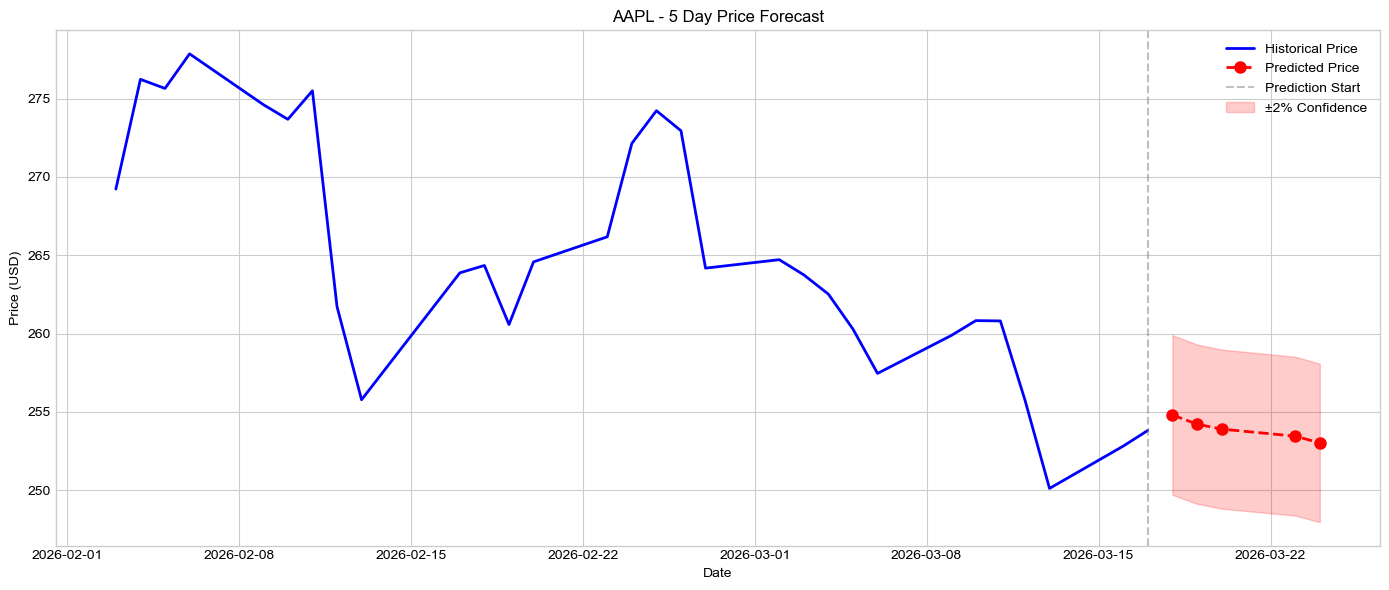

In [9]:
last_30_days = df['Close'].values[-30:]
last_30_dates = df.index[-30:]
future_dates = pd.bdate_range(start=df.index[-1], periods=n_days + 1)[1:]

plt.figure(figsize=(14, 6))
plt.plot(last_30_dates, last_30_days, label='Historical Price', color='blue', linewidth=2)
plt.plot(future_dates, predictions, label='Predicted Price', color='red', linewidth=2, linestyle='--', marker='o', markersize=8)
plt.axvline(x=df.index[-1], color='gray', linestyle='--', alpha=0.5, label='Prediction Start')
plt.fill_between(future_dates,
                 [p * 0.98 for p in predictions],
                 [p * 1.02 for p in predictions],
                 alpha=0.2, color='red', label='±2% Confidence')
plt.title(f'{ticker} - {n_days} Day Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Real-time prediction loop (run during market hours)

In [10]:
import time

print(f"Starting real-time predictions for {ticker}...")
print("Press Kernel > Interrupt to stop\n")

timestamps = []
actuals = []
preds = []
n_iterations = 10
wait_seconds = 60

for i in range(n_iterations):
    try:
        df_rt = fetch_realtime_data(ticker)

        if len(df_rt) < seq_length:
            print(f"Waiting for more data... ({len(df_rt)}/{seq_length} points)")
            time.sleep(wait_seconds)
            continue

        recent = df_rt[['Close']].values[-seq_length:]

        # Pad to match expected features if needed
        if scaler.n_features_in_ > 1:
            padded = np.zeros((len(recent), scaler.n_features_in_))
            padded[:, 0] = recent.flatten()
            scaled = scaler.transform(padded)
        else:
            scaled = scaler.transform(recent)

        pred_price = predict_next_price(model, scaled, scaler)
        actual_price = df_rt['Close'].iloc[-1]
        ts = df_rt.index[-1]

        timestamps.append(ts)
        actuals.append(actual_price)
        preds.append(pred_price)

        diff = pred_price - actual_price
        print(f"[{i+1}/{n_iterations}] {ts} | Actual: ${actual_price:.2f} | Predicted: ${pred_price:.2f} | Diff: ${diff:+.2f}")

        time.sleep(wait_seconds)

    except Exception as e:
        print(f"Error: {e}")
        time.sleep(wait_seconds)

print("\nReal-time loop complete.")


Real-time loop complete.


## Plot real-time results

In [ ]:
if len(timestamps) > 1:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(timestamps, actuals, label='Actual Price', color='blue', marker='o')
    axes[0].plot(timestamps, preds, label='Predicted Price', color='red', marker='x')
    axes[0].set_title(f'{ticker} - Real-Time Predictions')
    axes[0].set_ylabel('Price (USD)')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)

    errors = [a - p for a, p in zip(actuals, preds)]
    colors = ['green' if e >= 0 else 'red' for e in errors]
    axes[1].bar(range(len(errors)), errors, color=colors, alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_title('Prediction Errors')
    axes[1].set_ylabel('Error ($)')
    axes[1].set_xlabel('Prediction #')

    plt.tight_layout()
    plt.show()

    abs_errors = [abs(e) for e in errors]
    print(f"Average absolute error: ${np.mean(abs_errors):.2f}")
    print(f"Max error: ${np.max(abs_errors):.2f}")
    print(f"Min error: ${np.min(abs_errors):.2f}")
else:
    print("Not enough data points to plot. Run during market hours for best results.")

## Final dashboard

In [ ]:
print("\n")
print("╔" + "═" * 58 + "╗")
print("║" + f"  STOCK PREDICTION DASHBOARD - {ticker}".ljust(58) + "║")
print("╠" + "═" * 58 + "╣")
print("║" + f"  Model: LSTM ({config['source']})".ljust(58) + "║")
print("║" + f"  Sequence length: {seq_length} days".ljust(58) + "║")
print("║" + f"  Features: {len(selected_features)}".ljust(58) + "║")
print("║" + f"  Training RMSE: ${config['rmse']:.2f}".ljust(58) + "║")
print("║" + f"  Training MAE: ${config['mae']:.2f}".ljust(58) + "║")
print("║" + f"  MAPE: {config['mape']:.2f}%".ljust(58) + "║")
print("║" + f"  Prediction Accuracy: {config['accuracy_pct']:.2f}%".ljust(58) + "║")
print("╠" + "═" * 58 + "╣")
print("║" + f"  Current price: ${current_price:.2f}".ljust(58) + "║")
print("║" + f"  Next day prediction: ${predictions[0]:.2f}".ljust(58) + "║")
print("║" + f"  5-day range: ${min(predictions):.2f} - ${max(predictions):.2f}".ljust(58) + "║")
if len(actuals) > 1:
    print("║" + f"  Real-time avg error: ${np.mean(abs_errors):.2f}".ljust(58) + "║")
print("╠" + "═" * 58 + "╣")
print("║" + f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}".ljust(58) + "║")
print("╚" + "═" * 58 + "╝")